**Importing Libraries & Loading Data**

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = pd.read_csv('/content/mental_health_social_media_dataset.csv')




**Data Overview & Initial Exploration**


In [5]:
data.shape

(5000, 15)

In [6]:
data.columns

Index(['person_name', 'age', 'date', 'gender', 'platform',
       'daily_screen_time_min', 'social_media_time_min',
       'negative_interactions_count', 'positive_interactions_count',
       'sleep_hours', 'physical_activity_min', 'anxiety_level', 'stress_level',
       'mood_level', 'mental_state'],
      dtype='object')

I review the initial data information to understand the data types and missing values before starting the analysis.

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   person_name                  5000 non-null   object 
 1   age                          5000 non-null   int64  
 2   date                         5000 non-null   object 
 3   gender                       5000 non-null   object 
 4   platform                     5000 non-null   object 
 5   daily_screen_time_min        5000 non-null   int64  
 6   social_media_time_min        5000 non-null   int64  
 7   negative_interactions_count  5000 non-null   int64  
 8   positive_interactions_count  5000 non-null   int64  
 9   sleep_hours                  5000 non-null   float64
 10  physical_activity_min        5000 non-null   int64  
 11  anxiety_level                5000 non-null   int64  
 12  stress_level                 5000 non-null   int64  
 13  mood_level        

In [8]:
data.describe()

,age,daily_screen_time_min,social_media_time_min,negative_interactions_count,positive_interactions_count,sleep_hours,physical_activity_min,anxiety_level,stress_level,mood_level
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,29.947800,373.058200,175.331600,0.864200,1.835400,7.134660,22.693400,2.510400,7.107600,5.625800
std,12.279936,106.003916,71.209329,0.555176,0.943443,0.533184,10.602862,0.794996,1.062378,0.759928
min,13.000000,140.000000,35.000000,0.000000,0.000000,6.400000,8.000000,1.000000,5.000000,4.000000
25%,21.000000,310.000000,118.000000,1.000000,1.000000,6.700000,14.000000,2.000000,6.000000,5.000000
50%,27.000000,388.000000,170.000000,1.000000,2.000000,7.100000,21.000000,3.000000,7.000000,6.000000
75%,35.250000,461.000000,231.000000,1.000000,2.000000,7.450000,29.000000,3.000000,8.000000,6.000000
max,69.000000,520.000000,338.000000,2.000000,4.000000,8.300000,46.000000,4.000000,9.000000,7.000000


In [10]:
data.describe(include='object')

,person_name,date,gender,platform,mental_state
count,5000,5000,5000,5000,5000
unique,891,686,3,7,3
top,Navya Chauhan,11/6/2025,Female,Facebook,Stressed
freq,14,12,2474,744,4601


In [12]:
data.isnull().sum()

,0
person_name,0
age,0
date,0
gender,0
platform,0
daily_screen_time_min,0
social_media_time_min,0
negative_interactions_count,0
positive_interactions_count,0
sleep_hours,0


**Data Cleaning**


Cleaning the gender data to handle outliers and replacing them with the most frequent value to ensure more accurate results.

In [15]:
data['gender'].unique()

array(['Male', 'Female', 'Other'], dtype=object)

In [16]:
data['gender'] = data['gender'].replace('Other', np.nan)
mode_gender = data['gender'].mode()[0]
data['gender'] = data['gender'].fillna(mode_gender)

In [17]:
data.groupby('daily_screen_time_min')['gender'].value_counts()

daily_screen_time_min  gender
140                    Female     4
                       Male       1
141                    Male       6
                       Female     2
142                    Female     4
                                 ..
518                    Male      10
519                    Female    12
                       Male       8
520                    Female    14
                       Male       5
Name: count, Length: 682, dtype: int64

In [52]:
#Analyzing the average age by screen time duration to identify the most frequent user groups.
data.groupby('daily_screen_time_min')['age'].mean()

,age
daily_screen_time_min,
140,60.600000
141,58.000000
142,54.500000
143,56.714286
144,58.250000
...,...
516,22.068966
517,22.062500
518,22.080000


**Feature Engineering**

In [53]:
#Segmenting users into categories based on screen time to facilitate comparison between groups.
data['screen_time_group'] = pd.qcut(
    data['daily_screen_time_min'],
    q=4,   # number of categories
    labels=['Low', 'Medium', 'High', 'Very High']
)

data.groupby('screen_time_group')['age'].mean()


/tmp/ipython-input-3685929196.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby('screen_time_group')['age'].mean()


,age
screen_time_group,
Low,47.350400
Medium,29.883293
High,20.595711
Very High,21.965323


**Descriptive Analysis**

Comparing the average screen time between males and females.

/tmp/ipython-input-2492949138.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data= data.groupby('screen_time_group')['gender'].value_counts()


<Axes: title={'center': 'Gender Distribution by Screen Time Category'}>

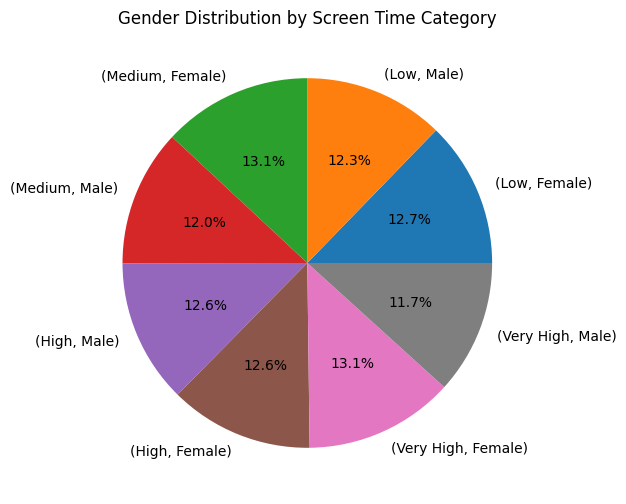

In [54]:
grouped_data= data.groupby('screen_time_group')['gender'].value_counts()
grouped_data.plot.pie(autopct="%1.1f%%", figsize=(6,6), ylabel="",  title="Gender Distribution by Screen Time Category")

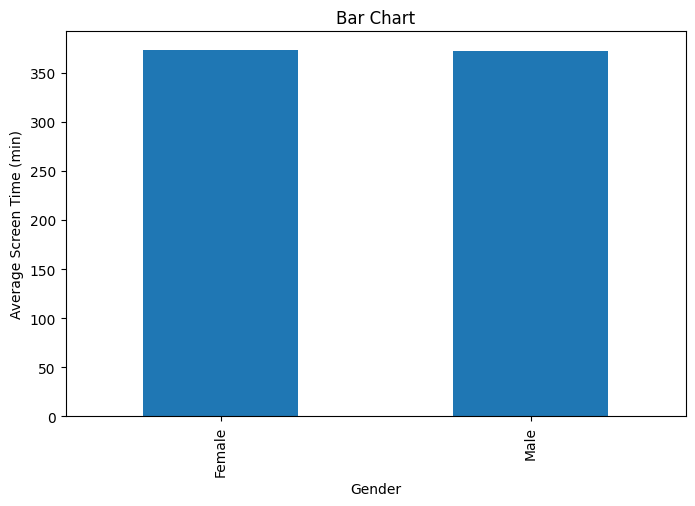

In [19]:
#Bar char
avgtimescreen=data.groupby('gender')['daily_screen_time_min'].mean()
avgtimescreen.plot(kind='bar', figsize=(8,5))

plt.title("Bar Chart")
plt.xlabel("Gender")#Label the X-axis
plt.ylabel("Average Screen Time (min)")#Label the Y-axis
plt.show()

In [20]:
data['gender'].value_counts()

,count
gender,
Female,2573
Male,2427


In [21]:
data['gender'].unique()


array(['Male', 'Female'], dtype=object)

In [22]:
avgtimescreen = data.groupby('gender')['daily_screen_time_min'].mean()
avgtimescreen


,daily_screen_time_min
gender,
Female,373.450447
Male,372.642357


In [23]:
data['platform'].unique()


array(['Instagram', 'Snapchat', 'Facebook', 'WhatsApp', 'TikTok',
       'YouTube', 'Twitter'], dtype=object)

In [24]:
data['platform'].value_counts()

,count
platform,
Facebook,744
TikTok,723
YouTube,716
WhatsApp,710
Snapchat,705
Instagram,703
Twitter,699


Identifying the platforms that consume the most user time.

In [25]:
avgtimescreen = data.groupby('platform')['daily_screen_time_min'].mean()
avgtimescreen

,daily_screen_time_min
platform,
Facebook,376.720430
Instagram,372.716927
Snapchat,366.140426
TikTok,372.824343
Twitter,370.340486
WhatsApp,382.480282
YouTube,369.945531


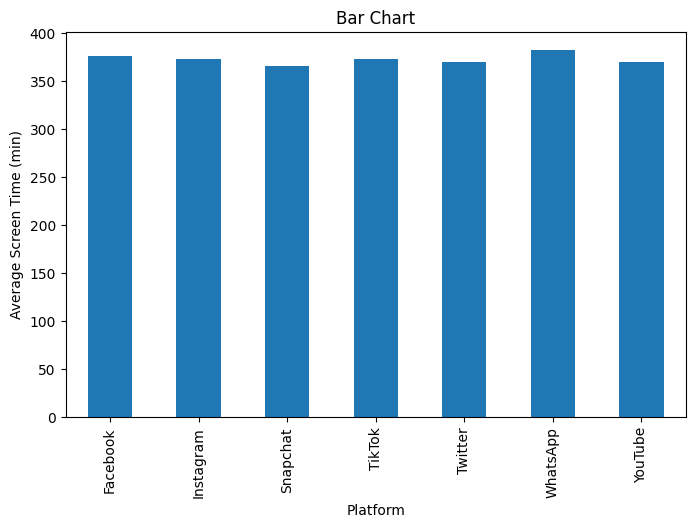

In [26]:
avgtimescreen=data.groupby('platform')['daily_screen_time_min'].mean()
avgtimescreen.plot(kind='bar', figsize=(8,5))

plt.title("Bar Chart")
plt.xlabel("Platform")#Label the X-axis
plt.ylabel("Average Screen Time (min)")#Label the Y-axis
plt.show()

Analyzing sleep hours by age and gender to understand behavioral differences.

In [27]:
#2. Average hours of sleep
data['sleep_hours'].mean()

np.float64(7.13466)

In [28]:
#Average sleep hours by gender
data.groupby('gender')['sleep_hours'].mean()

,sleep_hours
gender,
Female,7.132686
Male,7.136753


In [29]:
data.groupby('age')['sleep_hours'].mean()

,sleep_hours
age,
13,6.912844
14,6.888095
15,6.899010
16,6.893694
17,6.894681
18,6.880198
19,6.597736
20,6.605833
21,6.593585


In [30]:
data['age_group'] = pd.qcut(
    data['age'],
    q=10,   # number of categories
    labels=['10s', '20s', '30s', '40s','50s','60s','70s','80s','90s','100s']

)

data.groupby('age_group')['sleep_hours'].mean()

/tmp/ipython-input-3216437235.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby('age_group')['sleep_hours'].mean()


,sleep_hours
age_group,
10s,6.895167
20s,6.601584
30s,6.601578
40s,6.600992
50s,6.905295
60s,7.208911
70s,7.201681
80s,7.612360
90s,7.799332


In [31]:
#Most used platforms
#Number of users per platform

data['platform'].value_counts()

,count
platform,
Facebook,744
TikTok,723
YouTube,716
WhatsApp,710
Snapchat,705
Instagram,703
Twitter,699


In [32]:
#Average social media time per platform

data.groupby('platform')['social_media_time_min'].mean()

,social_media_time_min
platform,
Facebook,131.845430
Instagram,186.358464
Snapchat,201.378723
TikTok,242.333333
Twitter,148.127325
WhatsApp,95.640845
YouTube,221.969274


** Correlation & Relationships **

Examining the relationship between social media usage time and sleep duration to determine whether there is an inverse effect.

/tmp/ipython-input-764321482.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


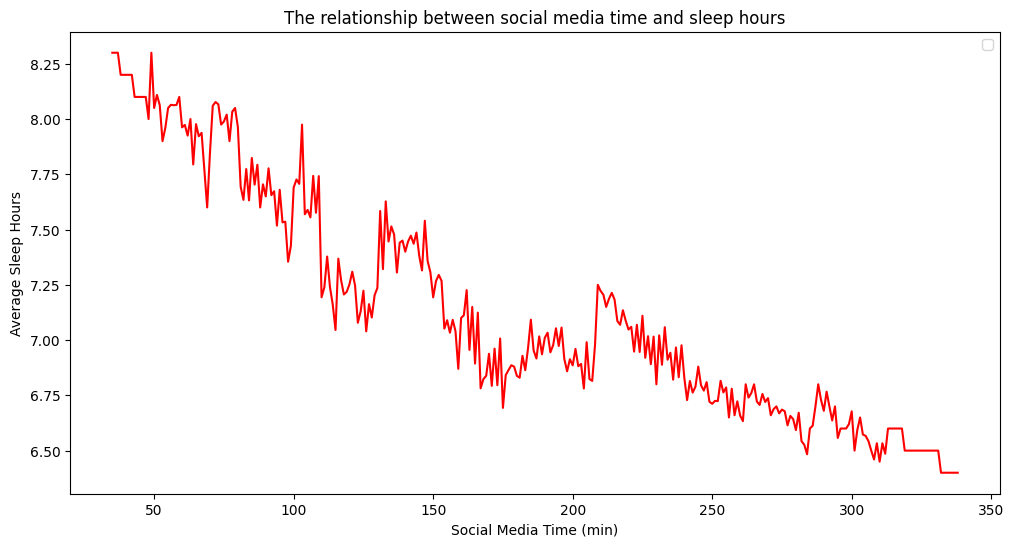

In [33]:
#The relationship between social media time and sleep hours
# Does increased time spent on social media reduce sleep?

socialtime_mean = data.groupby('social_media_time_min')['sleep_hours'].mean()
plt.figure(figsize=(12,6))
plt.plot(socialtime_mean.index,socialtime_mean.values,color='r')
plt.title("The relationship between social media time and sleep hours")
plt.xlabel("Social Media Time (min)")
plt.ylabel("Average Sleep Hours")
plt.legend()
plt.show()
#According to the line plot, increased social media use reduces sleep.

Testing the impact of negative interactions on sleep to determine whether they reduce sleep duration.

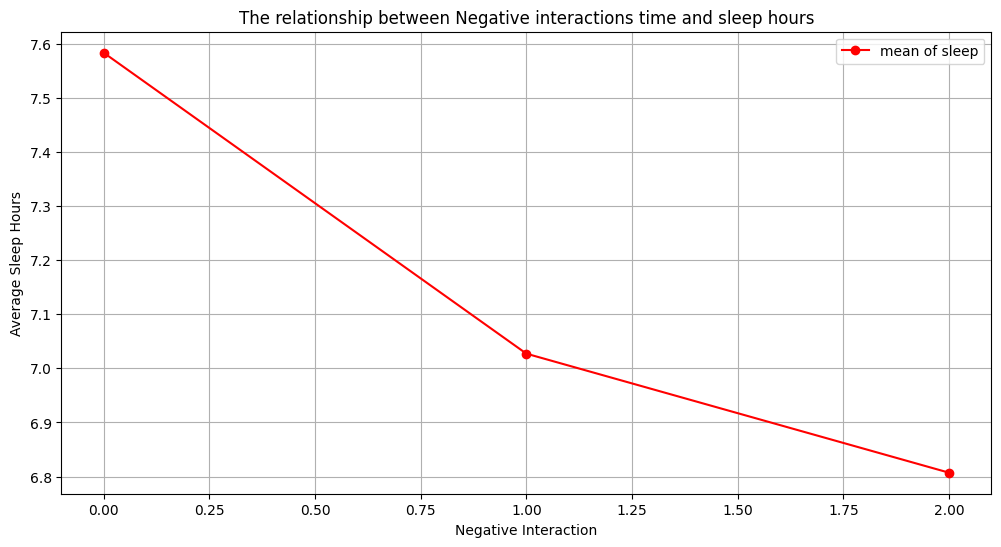

In [34]:
#The effect of negative interactions on sleep

#Does increased negative interaction lead to decreased sleep?
negative_mean = data.groupby('negative_interactions_count')['sleep_hours'].mean()
plt.figure(figsize=(12,6))
plt.plot(negative_mean.index,negative_mean.values,color='r',marker='o',label='mean of sleep')
plt.title("The relationship between Negative interactions time and sleep hours")
plt.xlabel("Negative Interaction")
plt.ylabel("Average Sleep Hours")
plt.legend()
plt.grid(True)
plt.show()
#According to the line plot, yes,
#negative interactions negatively affect the number of hours of sleep.


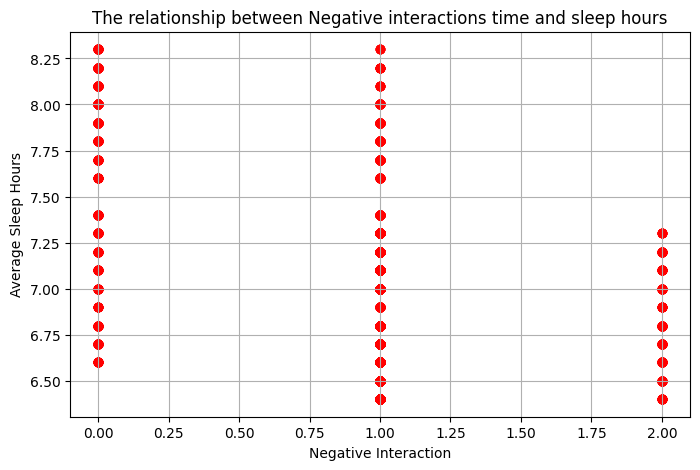

In [35]:
y=data['sleep_hours']
x=data['negative_interactions_count']

plt.figure(figsize=(8,5))
plt.scatter(x,y,color='r',alpha=0.5)#alpha for transparency
plt.title("The relationship between Negative interactions time and sleep hours")
plt.xlabel("Negative Interaction")#Label the X-axis
plt.ylabel("Average Sleep Hours")#Label the Y-axis
plt.grid(True)#Add grid
plt.show()#Display the plot
#According to the line plot, yes,
#negative interactions negatively affect the number of hours of sleep.

Analyzing whether positive interactions can offset the effects of negative interactions on the user.

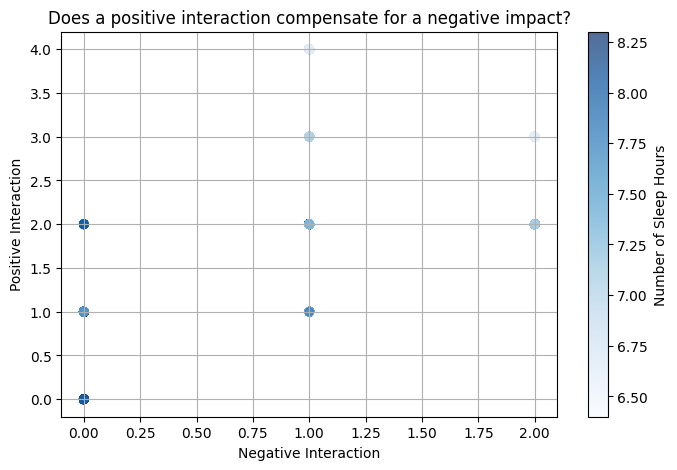

In [36]:

c=data['sleep_hours']
x=data['negative_interactions_count']
y=data['positive_interactions_count']

plt.figure(figsize=(8,5))
plt.scatter(x,y,c=c,cmap='Blues',alpha=0.7)#alpha for transparency
plt.title("Does a positive interaction compensate for a negative impact?")
plt.colorbar(label='Number of Sleep Hours')
plt.xlabel("Negative Interaction")#Label the X-axis
plt.ylabel("Positive Interaction")#Label the Y-axis
plt.grid(True)#Add grid
plt.show()#Display the plot
#According to the diagram, no, a positive comment doesn't always compensate for a negative one.

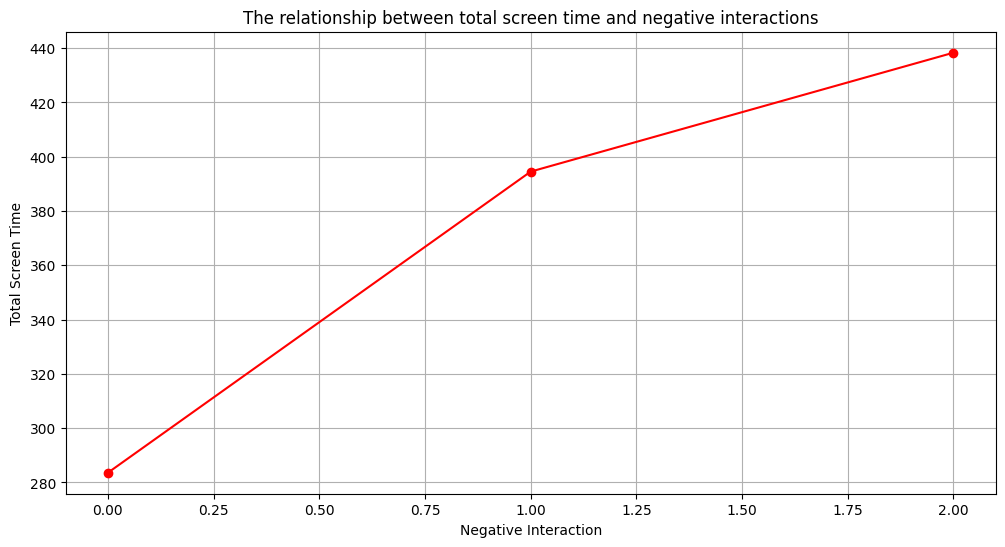

In [37]:
#Analyzing whether higher negative interactions are linked to longer screen time usage.
#The relationship between total screen time and negative interactions
#Does prolonged use increase the likelihood of negative experiences?
negativesoc = data.groupby('negative_interactions_count')['daily_screen_time_min'].mean()
plt.figure(figsize=(12,6))
plt.plot(negativesoc.index,negativesoc.values,color='r',marker='o',)
plt.title("The relationship between total screen time and negative interactions")
plt.xlabel("Negative Interaction")
plt.ylabel("Total Screen Time")
plt.grid(True)
plt.show()

**Grouped Analysis**

Comparing user behavior across different age groups in terms of usage, interactions, and sleep.

In [38]:
#Behavioral differences according to age group:
#Under 18
#18–25
#26–35
#36+

data['age_group']=pd.cut(data['age'],bins=[0,17,25,35,100],labels=['<18','18-25','26-35','36+',])


In [39]:
#Average screen time per age group
data.groupby('age_group')['daily_screen_time_min'].mean()

/tmp/ipython-input-1538657655.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby('age_group')['daily_screen_time_min'].mean()


,daily_screen_time_min
age_group,
<18,420.162325
18-25,476.598595
26-35,359.698571
36+,215.894400


In [40]:
#Average sleep hours for each age group
data.groupby('age_group')['sleep_hours'].mean()

/tmp/ipython-input-1473927446.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby('age_group')['sleep_hours'].mean()


,sleep_hours
age_group,
<18,6.898196
18-25,6.615289
26-35,7.202357
36+,7.922320


In [41]:
#Negative interactions by age
data.groupby('age_group')['negative_interactions_count'].mean()

/tmp/ipython-input-734568116.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby('age_group')['negative_interactions_count'].mean()


,negative_interactions_count
age_group,
<18,0.993988
18-25,1.061048
26-35,0.915714
36+,0.463200


In [42]:
#Positive interactions by age
data.groupby('age_group')['positive_interactions_count'].mean()

/tmp/ipython-input-3690465560.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby('age_group')['positive_interactions_count'].mean()


,positive_interactions_count
age_group,
<18,1.987976
18-25,2.333874
26-35,1.771429
36+,1.108000


In [43]:
#Comprehensive comparison of behavior
data.groupby('age_group')[['daily_screen_time_min','sleep_hours','negative_interactions_count','positive_interactions_count']].mean()

/tmp/ipython-input-2937388512.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby('age_group')[['daily_screen_time_min','sleep_hours','negative_interactions_count','positive_interactions_count']].mean()


,daily_screen_time_min,sleep_hours,negative_interactions_count,positive_interactions_count
age_group,,,,
<18,420.162325,6.898196,0.993988,1.987976
18-25,476.598595,6.615289,1.061048,2.333874
26-35,359.698571,7.202357,0.915714,1.771429
36+,215.894400,7.922320,0.463200,1.108000


In [44]:
#Analysis by Gender:
#Who spends more time on social media?

data.groupby('gender')['social_media_time_min'].mean()
 #There is no significant difference in the time spent by males and females
 #on social media in this data.

,social_media_time_min
gender,
Female,175.190828
Male,175.480841


In [45]:
#Analysis by Gender:
#Who experiences more negative interactions?
data.groupby('gender')['negative_interactions_count'].mean()
#Both sexes experience negative interactions at roughly the same rate.

,negative_interactions_count
gender,
Female,0.858531
Male,0.870210


Identifying which platforms are associated with increased negative behaviors or reduced sleep.

In [46]:
#Which platform has:
#More negative interactions?

data.groupby('platform')['negative_interactions_count'].mean().sort_values(ascending=False)

#TikTok is the platform where users experience the highest number of
 #negative interactions on average.
 #WhatsApp experiences the fewest negative interactions.

,negative_interactions_count
platform,
TikTok,1.659751
Twitter,0.934192
YouTube,0.920391
Snapchat,0.842553
Instagram,0.829303
Facebook,0.676075
WhatsApp,0.181690


In [47]:
#Comparing average sleep hours between platforms to identify
#which platforms are associated with lower sleep duration.

#Which platform has:
#Less sleep?
data.groupby('platform')['sleep_hours'].mean().sort_values()

#WhatsApp is associated with users who get the least average sleep
#(approximately 7.09 hours).

#Snapchat is associated with users who get the most average sleep
#(approximately 7.17 hours).


,sleep_hours
platform,
WhatsApp,7.087042
Facebook,7.116398
Instagram,7.136131
TikTok,7.136238
Twitter,7.148498
YouTube,7.149441
Snapchat,7.170071


In [48]:
#Longer usage?
data.groupby('platform')['social_media_time_min'].mean().sort_values()


#Users spend the most time on TikTok (around 4 hours daily).
#The least amount of time is spent on WhatsApp (around 1.5 hours daily).

,social_media_time_min
platform,
WhatsApp,95.640845
Facebook,131.845430
Twitter,148.127325
Instagram,186.358464
Snapchat,201.378723
YouTube,221.969274
TikTok,242.333333


**Time-Series Analysis**

Analyzing temporal changes to detect daily or seasonal patterns in sleep and negative experiences.

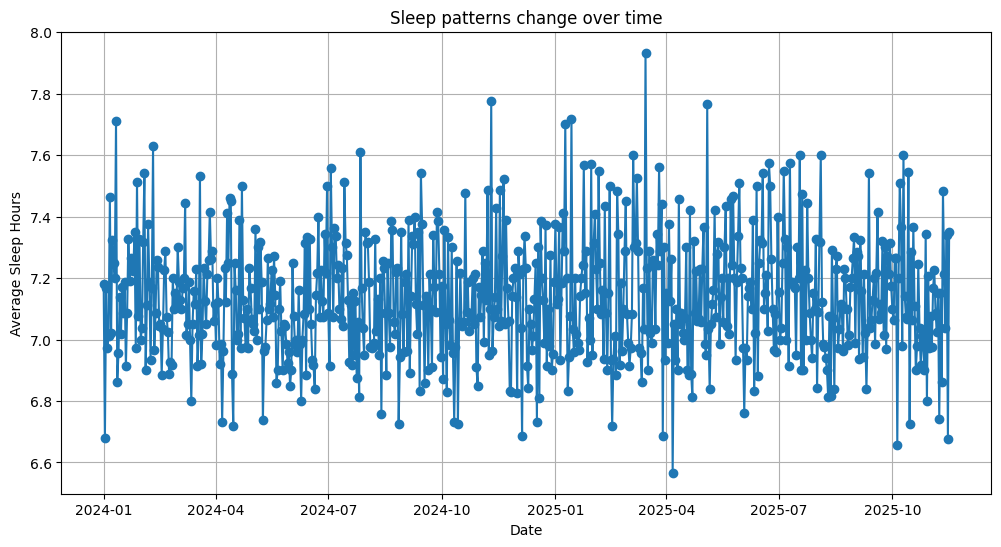

In [49]:
#Time-based Analysis
#Sleep patterns change over time
data['date']=pd.to_datetime(data['date'])
sleeptime= data.groupby('date')['sleep_hours'].mean()
plt.figure(figsize=(12,6))
plt.plot(sleeptime.index,sleeptime.values,marker='o',)
plt.title("Sleep patterns change over time")
plt.xlabel("Date")
plt.ylabel("Average Sleep Hours")
plt.grid(True)
plt.show()

#There does not appear to be a strong trend of increase or decrease
#over the time period; the most obvious thing is the daily fluctuation.

In [50]:
data.columns


Index(['person_name', 'age', 'date', 'gender', 'platform',
       'daily_screen_time_min', 'social_media_time_min',
       'negative_interactions_count', 'positive_interactions_count',
       'sleep_hours', 'physical_activity_min', 'anxiety_level', 'stress_level',
       'mood_level', 'mental_state', 'screen_time_group', 'age_group'],
      dtype='object')

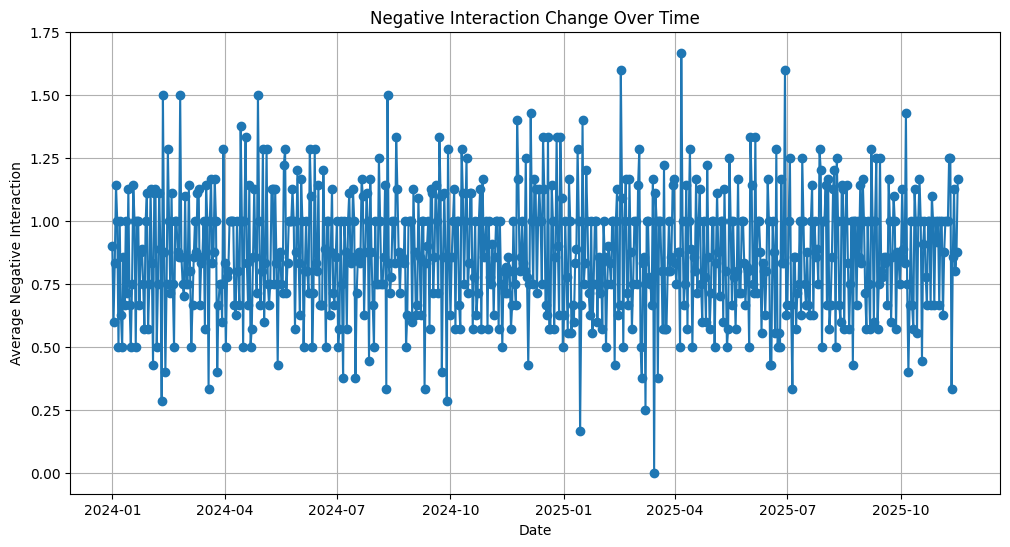

In [51]:
#How negative reactions change over time
#Are there certain days that are worse?
data['date']=pd.to_datetime(data['date'])
neginttime= data.groupby('date')['negative_interactions_count'].mean()
plt.figure(figsize=(12,6))
plt.plot(neginttime.index,neginttime.values,marker='o',)
plt.title("Negative Interaction Change Over Time")
plt.xlabel("Date")
plt.ylabel("Average Negative Interaction")
plt.grid(True)
plt.show()

#The average number of negative reactions per day ranges
#approximately between 0 and 1.7.

#There are clear daily fluctuations, meaning that some days have a significantly
#higher number of negative reactions.

#Overall, there is no clear long-term upward or downward trend; rather,
#the change is erratic and fluctuates daily.



**Key Findings**

*   Increased social media usage is associated with a decrease in sleep duration.

*  Platforms vary in their impact; for example, TikTok shows the highest usage and is accompanied by higher negative interactions.

*  There is no significant difference between genders in usage time.








**Conclusion**

This analysis demonstrates a clear connection between digital behavior and mental well-being indicators. Increased social media usage is consistently associated with reduced sleep duration, while platforms with higher engagement rates, particularly TikTok,show greater exposure to negative interactions. Although gender does not significantly influence usage patterns, age and platform choice appear to shape user experiences and outcomes. Overall, the findings highlight the importance of balancing social media activity and monitoring interaction quality to protect sleep stability and general well-being. Future work could expand these results by applying predictive models or collecting larger samples to validate and generalize the behavioral patterns observed.